In [57]:
from argparse import ArgumentParser


from Config.config import CONFIG
CONFIG = CONFIG("Reddit")


from DyGLib.models.GraphMixer import GraphMixer
from DyGLib.models.TGAT import TGAT
from DyGLib.models.TCL import TCL
from DyGLib.models.CAWN import CAWN
from DyGLib.models.DyGFormer import DyGFormer
from DyGLib.models.MemoryModel import MemoryModel, compute_src_dst_node_time_shifts

from DyGLib.models.modules import TGNN, NeuralNetworkSrcDst, BatchSubgraphs
from DyGLib.utils.DataLoader import get_link_prediction_data
from DyGLib.utils.utils import get_neighbor_sampler, NegativeEdgeSampler

import torch
import numpy as np
import pandas as pd
import seaborn as sns

import random

import graphviz
from IPython.display import SVG
import time

# # Initialization
trained_model_path = CONFIG.model.trained_model_path
edge_feat_path = CONFIG.data.folder + CONFIG.data.edge_feat_file
node_feat_path = CONFIG.data.folder + CONFIG.data.node_feat_file
index_path = CONFIG.data.folder + CONFIG.data.index_file
feature_names_path = CONFIG.data.folder + CONFIG.data.feature_names_file

# get data for training, validation and testing
node_raw_features, edge_raw_features, full_data, train_data, val_data, test_data = \
    get_link_prediction_data(val_ratio=0.1, test_ratio=0.1, node_dim=CONFIG.model.node_dim)

# initialize validation and test neighbor sampler to retrieve temporal graph
full_neighbor_sampler = get_neighbor_sampler(data=full_data, edge_features=edge_raw_features, sample_neighbor_strategy=CONFIG.model.sample_neighbor_strategy,
                                                time_scaling_factor=CONFIG.model.time_scaling_factor, seed=1)
train_neighbor_sampler = get_neighbor_sampler(data=train_data, edge_features=edge_raw_features, sample_neighbor_strategy=CONFIG.model.sample_neighbor_strategy,
                                                time_scaling_factor=CONFIG.model.time_scaling_factor, seed=1)

# create model
if CONFIG.model.model_name == 'TGAT':
    dynamic_backbone = TGAT(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name in ['JODIE', 'DyRep', 'TGN']:
    # four floats that represent the mean and standard deviation of source and destination node time shifts in the training data, which is used for JODIE
    src_node_mean_time_shift, src_node_std_time_shift, dst_node_mean_time_shift_dst, dst_node_std_time_shift = \
        compute_src_dst_node_time_shifts(train_data.src_node_ids, train_data.dst_node_ids, train_data.node_interact_times)
    dynamic_backbone = MemoryModel(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                                    time_feat_dim=CONFIG.model.time_feat_dim, model_name=CONFIG.model.model_name, num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads,
                                    dropout=CONFIG.model.dropout, src_node_mean_time_shift=src_node_mean_time_shift, src_node_std_time_shift=src_node_std_time_shift,
                                    dst_node_mean_time_shift_dst=dst_node_mean_time_shift_dst, dst_node_std_time_shift=dst_node_std_time_shift, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'CAWN':
    dynamic_backbone = CAWN(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, position_feat_dim=CONFIG.model.position_feat_dim, walk_length=CONFIG.model.walk_length,
                            num_walk_heads=CONFIG.model.num_walk_heads, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'TCL':
    dynamic_backbone = TCL(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads,
                            num_depths=CONFIG.model.num_neighbors + 1, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'GraphMixer':
    dynamic_backbone = GraphMixer(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                            time_feat_dim=CONFIG.model.time_feat_dim, num_tokens=CONFIG.model.num_neighbors, num_layers=CONFIG.model.num_layers, dropout=CONFIG.model.dropout, device=CONFIG.model.device)
elif CONFIG.model.model_name == 'DyGFormer':
    dynamic_backbone = DyGFormer(num_nodes=node_raw_features.shape[0], node_dim=node_raw_features.shape[1], edge_dim=edge_raw_features.shape[1],
                                    time_feat_dim=CONFIG.model.time_feat_dim, channel_embedding_dim=CONFIG.model.channel_embedding_dim, patch_size=CONFIG.model.patch_size,
                                    num_layers=CONFIG.model.num_layers, num_heads=CONFIG.model.num_heads, dropout=CONFIG.model.dropout,
                                    max_input_sequence_length=CONFIG.model.max_input_sequence_length, device=CONFIG.model.device)
else:
    raise ValueError(f"Wrong value for model_name {CONFIG.model.model_name}!")

regressor = NeuralNetworkSrcDst(input_dim=node_raw_features.shape[1], num_layers=CONFIG.model.num_reg_layers, hidden_dim=CONFIG.model.hidden_reg_layers_dim)
model = TGNN(dynamic_backbone, regressor)

model.load_state_dict(torch.load(trained_model_path, weights_only=True))
model.to(CONFIG.model.device)
model.eval()

num_samples = 200

def get_edge_by_id(link_index):
    src, dst, time_stamp, edge_id, true_value = full_data.src_node_ids[link_index], full_data.dst_node_ids[link_index], full_data.node_interact_times[link_index], full_data.edge_ids[link_index], 1 # type: ignore
    return src, dst, time_stamp, edge_id, true_value

random.seed(2025)
sampled_edge_ids = random.sample((np.where((~np.isnan(full_data.labels)) & (~np.isin(full_data.edge_ids, train_data.edge_ids)))[0]).tolist(), num_samples)
edge_info_array = np.array([list(get_edge_by_id(i)) for i in sampled_edge_ids])
edge_info = pd.DataFrame(edge_info_array, columns=["Src", "Dst", "Time", "Event", "Target"])
edges = edge_info["Event"].to_numpy(dtype=int)
edge_info["InTrain"] = np.isin(edges, train_data.edge_ids)
edge_info = edge_info.sort_values(by="InTrain").reset_index(drop=True)
edge_info = edge_info[edge_info.InTrain == False]
srcs = edge_info["Src"].to_numpy(dtype=int)
dsts = edge_info["Dst"].to_numpy(dtype=int)
timestamps = edge_info["Time"].to_numpy(dtype="float32")
targets = edge_info["Target"].to_numpy(dtype="float32")

model.eval()

subgraphs_src = full_neighbor_sampler.get_multi_hop_neighbors(CONFIG.model.num_layers, srcs, timestamps, num_neighbors = CONFIG.model.num_neighbors)
subgraphs_dst = full_neighbor_sampler.get_multi_hop_neighbors(CONFIG.model.num_layers, dsts, timestamps, num_neighbors = CONFIG.model.num_neighbors)
edge_feat_src = full_neighbor_sampler.get_edge_features_for_multi_hop(subgraphs_src[1])
edge_feat_dst = full_neighbor_sampler.get_edge_features_for_multi_hop(subgraphs_dst[1])

subgraphs_src = BatchSubgraphs(*subgraphs_src, edge_feat_src)
subgraphs_src.to(CONFIG.model.device)
subgraphs_dst = BatchSubgraphs(*subgraphs_dst, edge_feat_dst)
subgraphs_dst.to(CONFIG.model.device)

predicts = model(src_node_ids=srcs,
                dst_node_ids=dsts,
                node_interact_times=timestamps,
                src_subgraphs = subgraphs_src,
                dst_subgraphs = subgraphs_dst,
                time_gap=CONFIG.model.time_gap,
                edges_are_positive=True).squeeze(dim=-1).sigmoid()

edge_info["Prediction"] = predicts.detach().cpu().numpy()

edge_info.head()


The dataset has 672447 interactions, involving 10984 different nodes
The training dataset has 435435 interactions, involving 9633 different nodes
The validation dataset has 67245 interactions, involving 9242 different nodes
The test dataset has 67245 interactions, involving 9028 different nodes
The new node validation dataset has 14378 interactions, involving 3239 different nodes
The new node test dataset has 14782 interactions, involving 3151 different nodes
1098 nodes were used for the inductive testing, i.e. are never seen during training


,Src,Dst,Time,Event,Target,InTrain,Prediction
0,4632.000,10006.000,2303458.287,581647.000,1.000,False,0.999
1,9969.000,10468.000,2315471.742,585177.000,1.000,False,0.762
2,870.000,10006.000,907622.387,218998.000,1.000,False,0.780
3,2807.000,10212.000,2242424.197,567113.000,1.000,False,0.899
4,7179.000,10017.000,2105738.914,529198.000,1.000,False,1.000


In [58]:
sample_edge = edge_info.iloc[0]
src, dst, timestamp = int(sample_edge["Src"]), int(sample_edge["Dst"]), sample_edge["Time"]
src,dst,timestamp

(4632, 10006, np.float64(2303458.287))

In [59]:
timings = []


from Explainers.Shapley4TGNN.Explainer import ShapleyExplainerEvents
explainer = ShapleyExplainerEvents(model, full_neighbor_sampler, full_data, edge_raw_features)
start = time.time_ns()
explainer.initialize()
end = time.time_ns()
timings.append(np.array([[end-start, "Shapley4TGNNEvent", "Init"]]))

pd.set_option('display.float_format', lambda x: '%.3f' % x)

expl_shapley = explainer.explain_instance(src, dst, timestamp)
coalition_shapley, src_graph, dst_graph = explainer.build_coalitions(expl_shapley)
coalition_shapley[-1]

100%|██████████| 1/1 [00:01<00:00,  1.24s/it]


array([581613., 581577., 581468., 581118., 580519., 581213., 581355.,
       498707., 343916., 580727., 568574., 515267., 549431., 581112.,
       517706., 569575., 580375., 420501., 382392., 556823., 298956.,
       509240., 546189., 517014., 546701., 563998., 490187., 519822.,
       568921., 560380., 543693., 578624., 580146., 510033., 540774.,
       580029., 577393., 519337., 482447., 424569., 569678., 540682.,
        37405., 331855., 578399., 516508., 361132., 523020., 515643.,
       543864., 518907., 361082., 491214., 537340., 545191., 459270.,
       423249., 564798., 368052., 577445., 512694., 578664., 547392.,
       580752., 578180., 578211., 580026., 514397., 510306., 507147.,
       448698., 544661., 420243., 509791., 554673., 515109., 546376.,
        36792., 537648., 499829., 516347., 563617., 547150., 577305.,
       567542., 424184., 578073., 572836., 380933., 518935., 552494.,
       496344., 509642., 340953., 515412., 516026., 365294., 509533.,
       577872., 5068

<Axes: >

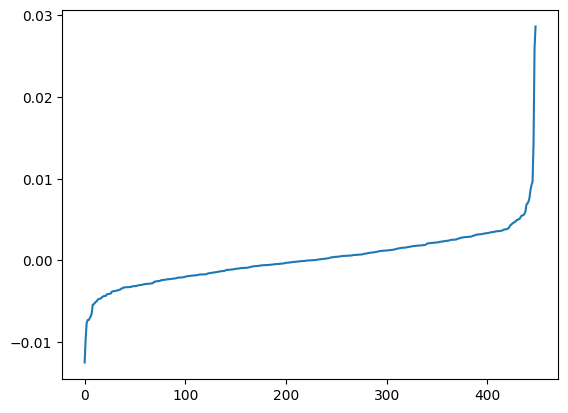

In [60]:
sns.lineplot(y = np.sort(expl_shapley[1].values).reshape(-1), x = np.array(list(range(expl_shapley[1].values.shape[1]))))

In [63]:
expl_shapley[1].values[np.abs(expl_shapley[1].values) >= 0.005].shape

(31,)

In [35]:
explainer.evaluate(np.array([src]), np.array([dst]), np.array([timestamp]), np.array([1]), edge_raw_features)[0].head(52)

100%|██████████| 1/1 [00:02<00:00,  2.74s/it]


,Original prediction,Ground truth,y,Sparsity thresholds,Fidelity to prediction,Fidelity to prediction (logit),Deviation to ground truth,GEF,Accuracy,Remove technique
0,0.999,1.000,0.762,0.000,-0.238,-6.332,-0.238,1.000,0.967,Zero
1,0.999,1.000,0.762,0.001,-0.238,-6.332,-0.238,1.000,0.967,Zero
2,0.999,1.000,0.762,0.001,-0.238,-6.332,-0.238,1.000,0.967,Zero
3,0.999,1.000,0.762,0.002,-0.238,-6.332,-0.238,1.000,0.967,Zero
4,0.999,1.000,0.762,0.002,-0.238,-6.332,-0.238,1.000,0.967,Zero
5,0.999,1.000,0.999,0.003,-0.000,-0.441,-0.001,1.000,1.000,Zero
6,0.999,1.000,0.999,0.004,-0.000,-0.441,-0.001,1.000,1.000,Zero
7,0.999,1.000,0.997,0.005,-0.002,-1.627,-0.003,1.000,1.000,Zero
8,0.999,1.000,1.000,0.007,-0.001,5.438,-0.000,1.000,1.000,Zero
9,0.999,1.000,1.000,0.009,-0.001,5.438,-0.000,1.000,1.000,Zero


In [36]:
coalition_shapley[-1].shape

(449,)

In [37]:
from Explainers.External.TempME.Explainer import TempMEExplainer
from Explainers.External.TempME.utils.graph import get_walk_finder

preprocessing = False

if(preprocessing):
    explainer = TempMEExplainer(model, train_neighbor_sampler, train_data)
    walk_finder = get_walk_finder(train_data)
    neg_edge_sampler = NegativeEdgeSampler(train_data.src_node_ids, train_data.dst_node_ids, train_data.node_interact_times)

    #explainer.preprocess(walk_finder, neg_edge_sampler, train=True)
    #explainer.initialize(train = True)
    explainer = TempMEExplainer(model, full_neighbor_sampler, full_data)
    walk_finder = get_walk_finder(full_data)
    neg_edge_sampler = NegativeEdgeSampler(full_data.src_node_ids, full_data.dst_node_ids, full_data.node_interact_times)
    explainer.preprocess(walk_finder, neg_edge_sampler, train=False)

start = time.time_ns()
explainer = TempMEExplainer(model, full_neighbor_sampler, full_data)
explainer.initialize(train = False)
end = time.time_ns()
timings.append(np.array([[end-start, "TempME", "Init"]]))


In [48]:
expl_tempme = explainer.explain_instance(src, dst, timestamp)

In [49]:
attentions = np.hstack(expl_tempme[0].event_attention)
events = np.hstack(expl_tempme[0].events)

In [56]:
attentions[attentions != 0].shape

(93,)

<Axes: >

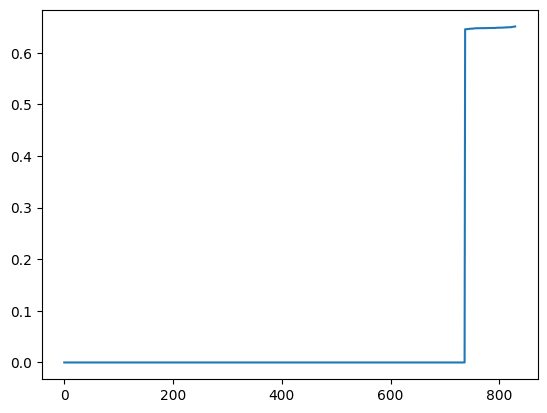

In [46]:
attentions = np.hstack(expl_tempme[0].event_attention)
events = np.hstack(expl_tempme[0].events)

attentions = attentions[events != 0]
attentions = attentions.flatten()

sns.lineplot(y = np.sort(attentions), x = np.array(list(range(attentions.shape[0]))))

In [10]:

expl_tempme = explainer.explain_instance(src, dst, timestamp)
coalition_tempme, src_graph, dst_graph = explainer.build_coalitions(expl_tempme)
coalition_tempme[-1]

KeyboardInterrupt: 

In [ ]:
explainer.build_coalitions(expl_tempme)

(array([[25083.,     0.,     0., ...,     0.,     0.,     0.],
        [25083.,     0.,     0., ...,     0.,     0.,     0.],
        [25083., 25094.,     0., ...,     0.,     0.,     0.],
        ...,
        [ 1540.,  1747.,  1942., ..., 39244., 39254., 39444.],
        [ 1540.,  1747.,  1942., ..., 39244., 39254., 39444.],
        [ 1540.,  1747.,  1942., ..., 39244., 39254., 39444.]]),
 <DyGLib.utils.utils.BatchSubgraphs at 0x761164173280>)

In [ ]:
coalition_shapley[-1].shape

(132,)

In [ ]:
coalition_tempme[-1].shape

(132,)

In [ ]:
np.isin(coalition_shapley[-1], coalition_tempme[-1])

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [ ]:
results_list = []

In [ ]:
from Explainers.Shapley4TGNN.Explainer import ShapleyExplainerEvents
explainer = ShapleyExplainerEvents(model, full_neighbor_sampler, full_data, edge_raw_features)
start = time.time_ns()
explainer.initialize()
end = time.time_ns()
timings.append(np.array([[end-start, "Shapley4TGNNEvent", "Init"]]))

pd.set_option('display.float_format', lambda x: '%.3f' % x)
result_shapley_edge, exec_times = explainer.evaluate(srcs, dsts, timestamps, targets, edge_raw_features)
timings.append(np.hstack([exec_times, np.full(exec_times.shape, "Shapley4TGNNEvent"), np.full(exec_times.shape, "Explain")]))
result_shapley_edge["Explainer"] = "Shapley4TGNNEvent"
results_list.append(result_shapley_edge)

100%|██████████| 200/200 [05:24<00:00,  1.62s/it]


In [ ]:
from Explainers.External.TempME.Explainer import TempMEExplainer
from Explainers.External.TempME.utils.graph import get_walk_finder

preprocessing = False

if(preprocessing):
    explainer = TempMEExplainer(model, train_neighbor_sampler, train_data)
    walk_finder = get_walk_finder(train_data)
    neg_edge_sampler = NegativeEdgeSampler(train_data.src_node_ids, train_data.dst_node_ids, train_data.node_interact_times)

    explainer.preprocess(walk_finder, neg_edge_sampler, train=True)
    explainer.initialize(train = True)
    explainer = TempMEExplainer(model, full_neighbor_sampler, full_data)
    walk_finder = get_walk_finder(full_data)
    neg_edge_sampler = NegativeEdgeSampler(full_data.src_node_ids, full_data.dst_node_ids, full_data.node_interact_times)
    explainer.preprocess(walk_finder, neg_edge_sampler, train=False)

start = time.time_ns()
explainer = TempMEExplainer(model, full_neighbor_sampler, full_data)
explainer.initialize(train = False)
end = time.time_ns()
timings.append(np.array([[end-start, "TempME", "Init"]]))

result_tempme, exec_times = explainer.evaluate(srcs, dsts, timestamps, targets, edge_raw_features)
timings.append(np.hstack([exec_times, np.full(exec_times.shape, "TempME"), np.full(exec_times.shape, "Explain")]))
result_tempme["Explainer"] = "TempME"
results_list.append(result_tempme)

100%|██████████| 200/200 [03:30<00:00,  1.05s/it]


In [ ]:
from Config.colors import PALLETTE2, PRIMARYCOLOR
import matplotlib.pyplot as plt

df = pd.concat(results_list)
df.head()


,Original prediction,Ground truth,y,Sparsity thresholds,Fidelity to prediction,Fidelity to prediction (logit),Deviation to ground truth,GEF,Accuracy,Remove technique,Explainer
0,0.842,1.000,0.895,0.000,-0.189,0.454,-0.105,0.845,0.000,Zero,Shapley4TGNNEvent
1,0.842,1.000,0.895,0.001,-0.189,0.454,-0.105,0.845,0.000,Zero,Shapley4TGNNEvent
2,0.842,1.000,0.895,0.001,-0.189,0.454,-0.105,0.845,0.000,Zero,Shapley4TGNNEvent
3,0.842,1.000,0.895,0.002,-0.189,0.454,-0.105,0.845,0.000,Zero,Shapley4TGNNEvent
4,0.842,1.000,0.890,0.002,-0.184,0.295,-0.110,0.850,0.000,Zero,Shapley4TGNNEvent


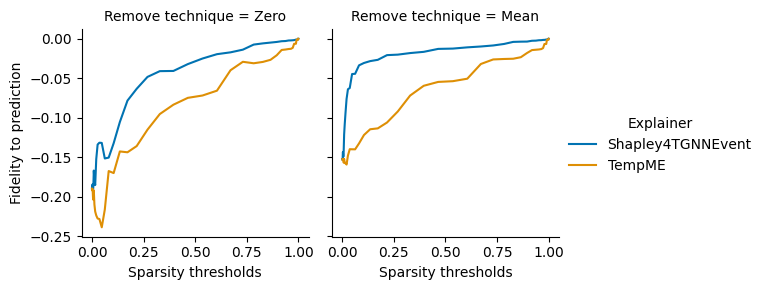

In [ ]:

g = sns.FacetGrid(df, col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Fidelity to prediction")
g.add_legend()


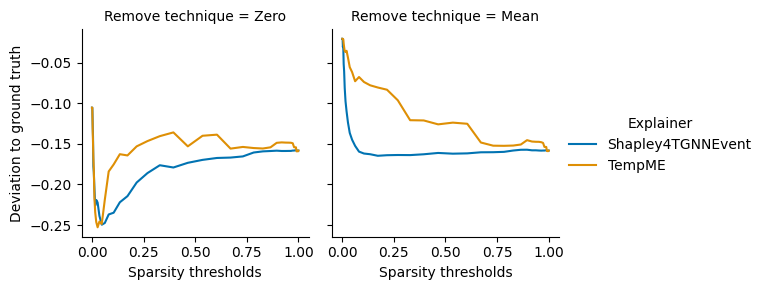

In [ ]:

g = sns.FacetGrid(df, col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Deviation to ground truth")
g.add_legend()


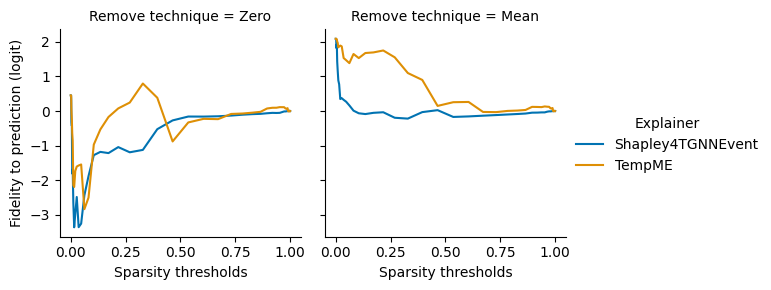

In [ ]:
g = sns.FacetGrid(df, col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="Fidelity to prediction (logit)")
g.add_legend()

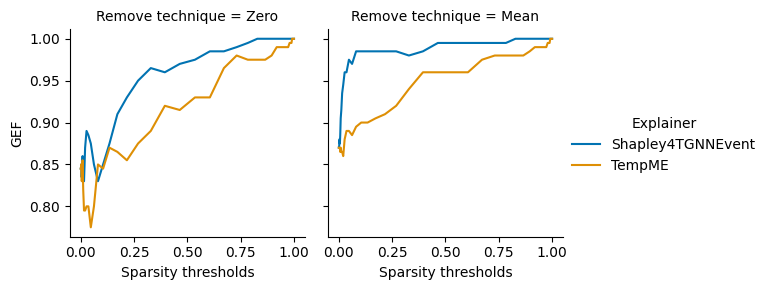

In [ ]:

g = sns.FacetGrid(df, col="Remove technique", hue="Explainer", legend_out=True, palette=PALLETTE2)
g.map_dataframe(sns.lineplot, x="Sparsity thresholds", y="GEF")
g.add_legend()
